# Preprocessing Optic Cup → SegTran format

Este notebook prepara todos os datasets de optic cup para o SegTran:

1. **REFUGE split**: merge of train/val/test (1200 images) → 960 train / 240 test
2. **Disc crop (Step 1)**: uses the DiscSeg model to detect the optic disc and crop a 560×560 region around it — for all datasets (REFUGE train/test, ORIGA, G1020)
3. **MNet training (Step 2)**: fine-tune of MNet DeepCDR using the REFUGE train crops
4. **MNet inference (Step 3)**: applies the trained MNet on all datasets
5. **List file generation**: `train.list`, `test.list`, `all.list` for SegTran
6. **Normalization statistics**: mean/std per dataset with gray_alpha=0.5
7. **Stats JSON update** + patching SegTran code

---
**Prerequisite**: place the pre-trained models in  
`segtran-master/code/MNet_DeepCDR/deep_model/`:
- `Model_DiscSeg_ORIGA.h5` — https://github.com/HzFu/MNet_DeepCDR
- `Model_MNet_REFUGE.h5` — https://github.com/HzFu/MNet_DeepCDR

In [10]:
import os
import sys
import json
import random
import shutil
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print('Bibliotecas base carregadas.')

Bibliotecas base carregadas.


In [11]:
# ─── Main paths ───────────────────────────────────────────────────────
BASE_DIR      = './'
SEGTRAN_DIR   = os.path.join(BASE_DIR, 'segtran')
CODE_DIR      = os.path.join(SEGTRAN_DIR, 'code')
MNET_DIR      = os.path.join(CODE_DIR, 'MNet_DeepCDR')
DEEP_MODEL    = os.path.join(MNET_DIR, 'deep_model')
DATA_DIR      = os.path.join(SEGTRAN_DIR, 'data', 'fundus')

DATASETS_DIR  = os.path.join(BASE_DIR, 'datasets', 'Optic_Cup')
REFUGE_DIR    = os.path.join(DATASETS_DIR, 'REFUGE')
ORIGA_DIR     = os.path.join(DATASETS_DIR, 'ORIGA')
G1020_DIR     = os.path.join(DATASETS_DIR, 'G1020')

# Pre-trained models
DISCSEG_MODEL = os.path.join(DEEP_MODEL, 'Model_DiscSeg_ORIGA.h5')
MNET_MODEL    = os.path.join(DEEP_MODEL, 'Model_MNet_REFUGE.h5')
MNET_TRAINED  = os.path.join(DEEP_MODEL, 'Model_MNet_REFUGE_finetuned.h5')

# Crop parameters
# DISC_ROI_SIZE deve coincidir com orig_input_size=576 do SegTran:
# train_util.py passa chosen_size=args.orig_input_size[0]=576 ao SegCrop,
# which filters files by the _{size}_ pattern in the name — _560_ crops would be ignored.
DISC_ROI_SIZE  = 576   # tamanho do crop do disco
DISCSEG_SIZE   = 640   # DiscSeg model resolution
MNET_SIZE      = 400   # MNet resolution

SEED = 42
N_TRAIN, N_TEST = 960, 240

os.makedirs(DEEP_MODEL, exist_ok=True)
os.makedirs(DATA_DIR,   exist_ok=True)

# Verifica modelos
for p, name in [(DISCSEG_MODEL, 'Model_DiscSeg_ORIGA.h5'), (MNET_MODEL, 'Model_MNet_REFUGE.h5')]:
    status = '✓' if os.path.exists(p) else '✗ MISSING'
    print(f'  [{status}] {name}')

print(f'\nData dir: {DATA_DIR}')


  [✓] Model_DiscSeg_ORIGA.h5
  [✓] Model_MNet_REFUGE.h5

Data dir: ./segtran/data/fundus


## 1. Split REFUGE: 960 treino / 240 teste

In [12]:
# Collects all images from the three original REFUGE splits
def collect_refuge_split(split_name, img_ext_candidates=('.jpg', '.png')):
    """Returns list of (img_path, mask_path) for a REFUGE split."""
    img_dir  = os.path.join(REFUGE_DIR, split_name, 'Images')
    mask_dir = os.path.join(REFUGE_DIR, split_name, 'Masks')
    pairs = []
    for fname in sorted(os.listdir(img_dir)):
        stem, ext = os.path.splitext(fname)
        if ext.lower() not in img_ext_candidates:
            continue
        mask_path = os.path.join(mask_dir, stem + '.png')
        if not os.path.exists(mask_path):
            print(f'  [warning] mask not found for {fname}')
            continue
        pairs.append((os.path.join(img_dir, fname), mask_path))
    return pairs

all_refuge = []
for split in ['train', 'val', 'test']:
    split_pairs = collect_refuge_split(split)
    print(f'  REFUGE {split:5s}: {len(split_pairs)} pares')
    all_refuge.extend(split_pairs)

print(f'\nTotal REFUGE: {len(all_refuge)} pares')

# Embaralha e divide
random.seed(SEED)
shuffled = all_refuge.copy()
random.shuffle(shuffled)

refuge_train_pairs = shuffled[:N_TRAIN]
refuge_test_pairs  = shuffled[N_TRAIN:N_TRAIN + N_TEST]

print(f'Treino REFUGE: {len(refuge_train_pairs)}')
print(f'Teste  REFUGE: {len(refuge_test_pairs)}')

  REFUGE train: 400 pares
  REFUGE val  : 400 pares
  REFUGE test : 400 pares

Total REFUGE: 1200 pares
Treino REFUGE: 960
Teste  REFUGE: 240


In [13]:
# Coleta pares ORIGA e G1020
def collect_dataset(img_dir, mask_dir, img_exts=('.jpg', '.png')):
    pairs = []
    for fname in sorted(os.listdir(img_dir)):
        stem, ext = os.path.splitext(fname)
        if ext.lower() not in img_exts:
            continue
        mask_path = os.path.join(mask_dir, stem + '.png')
        if not os.path.exists(mask_path):
            continue
        pairs.append((os.path.join(img_dir, fname), mask_path))
    return pairs

origa_pairs = collect_dataset(
    os.path.join(ORIGA_DIR, 'Images'),
    os.path.join(ORIGA_DIR, 'Masks')
)
g1020_pairs = collect_dataset(
    os.path.join(G1020_DIR, 'Images'),
    os.path.join(G1020_DIR, 'Masks')
)

print(f'ORIGA: {len(origa_pairs)} pares')
print(f'G1020: {len(g1020_pairs)} pares')

ORIGA: 650 pares
G1020: 1020 pares


## 2. Mask conversion and crop functions

In [14]:
def convert_mask_to_3channel(mask_array):
    """Converts mask {0=bg, 1=disc, 2=cup} to 3-channel SegTran format.
    
    Output (H, W, 3) uint8:
      Channel 0: 255 where disc or cup (>= 1)
      Channel 1: 255 where cup (== 2)
      Canal 2: 0
    """
    H, W = mask_array.shape[:2]
    out = np.zeros((H, W, 3), dtype=np.uint8)
    out[mask_array >= 1, 0] = 255  # disco (inclui cup)
    out[mask_array == 2, 1] = 255  # cup
    return out


def disc_crop(org_img, disc_roi_size, C_x, C_y):
    """Crops a square disc_roi_size × disc_roi_size region centered at (C_x, C_y).
    
    Retorna (region, crop_coord) onde crop_coord = [top, bottom, left, right].
    """
    half = disc_roi_size // 2
    top    = C_x - half
    bottom = C_x + half
    left   = C_y - half
    right  = C_y + half

    # Ajusta bordas
    if top < 0:
        top, bottom = 0, disc_roi_size
    if left < 0:
        left, right = 0, disc_roi_size
    if bottom > org_img.shape[0]:
        bottom = org_img.shape[0]
        top    = bottom - disc_roi_size
    if right > org_img.shape[1]:
        right = org_img.shape[1]
        left  = right - disc_roi_size

    region = org_img[top:bottom, left:right]
    return region, [top, bottom, left, right]


print('Mask conversion and crop functions defined.')

Mask conversion and crop functions defined.


In [15]:
import shutil, os

DATA_DIR = './segtran/data/fundus'
for ds in ['refuge_train', 'refuge_test', 'origa', 'g1020']:
    for subdir in ['images', 'masks']:
        p = os.path.join(DATA_DIR, ds, subdir)
        if os.path.exists(p):
            shutil.rmtree(p)
            os.makedirs(p)
            print(f'Cleared {p}')


Cleared ./segtran/data/fundus/refuge_train/images
Cleared ./segtran/data/fundus/refuge_train/masks
Cleared ./segtran/data/fundus/refuge_test/images
Cleared ./segtran/data/fundus/refuge_test/masks
Cleared ./segtran/data/fundus/origa/images
Cleared ./segtran/data/fundus/origa/masks
Cleared ./segtran/data/fundus/g1020/images
Cleared ./segtran/data/fundus/g1020/masks


## 3. Carrega modelo DiscSeg e aplica disc crop (Step 1)

In [16]:
# Configura TensorFlow e importa modelos MNet_DeepCDR
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

sys.path.insert(0, MNET_DIR)

from mnet_deep_cdr import Model_DiscSeg as DiscSegModel
from mnet_deep_cdr import Model_MNet    as MNetModel
from mnet_deep_cdr.mnet_utils import BW_img, pro_process, disc_crop
from skimage.measure import label, regionprops
from skimage.transform import resize as sk_resize

print('TF/MNet_DeepCDR imports complete.')

assert os.path.exists(MNET_MODEL) and os.path.getsize(MNET_MODEL) > 0, (
    f'Modelo MNet ausente ou vazio em:\n  {MNET_MODEL}\n'
    'Baixe Model_MNet_REFUGE.h5 de https://github.com/HzFu/MNet_DeepCDR e coloque nessa pasta.'
)

# Load DiscSeg if available; otherwise use MNet as disc detector.
# Ambos seguem a mesma interface do Step_1_Disc_Crop.py:
#   - entrada: (1, size, size, 3) float em [0, 255]
#   - used output: disc probability map at (size, size)
if os.path.exists(DISCSEG_MODEL) and os.path.getsize(DISCSEG_MODEL) > 0:
    disc_detector     = DiscSegModel.DeepModel(size_set=DISCSEG_SIZE)
    disc_detector.load_weights(DISCSEG_MODEL)
    disc_detector_size = DISCSEG_SIZE
    disc_detector_mode = 'discseg'
    print(f'DiscSeg carregado (modelo original): {DISCSEG_MODEL}')
else:
    # MNet also produces a disc map (channel 0 of the last output).
    # Works as a proxy for DiscSeg when the original model is not available.
    disc_detector      = MNetModel.DeepModel(size_set=MNET_SIZE)
    disc_detector.load_weights(MNET_MODEL)
    disc_detector_size = MNET_SIZE
    disc_detector_mode = 'mnet'
    print(f'[aviso] Model_DiscSeg_ORIGA.h5 ausente — usando MNet como detector de disco.')
    print(f'MNet carregado: {MNET_MODEL}')

# Separate MNet for disc/cup inference (Step 3)
mnet_seg = MNetModel.DeepModel(size_set=MNET_SIZE)
mnet_seg.load_weights(MNET_MODEL)
print(f'MNet loaded for segmentation: {MNET_MODEL}')


TF/MNet_DeepCDR imports complete.
DiscSeg carregado (modelo original): ./segtran/code/MNet_DeepCDR/deep_model/Model_DiscSeg_ORIGA.h5
MNet loaded for segmentation: ./segtran/code/MNet_DeepCDR/deep_model/Model_MNet_REFUGE.h5


In [17]:
def detect_disc_center_nn(orig_img, detector_model, detector_size, detector_mode):
    """Detects the optic disc center using a neural network — original Step_1_Disc_Crop.py.

    Follows exactly the logic of Step_1_Disc_Crop.py:
      1. Redimensiona a imagem para detector_size × detector_size
      2. Roda o modelo para obter o mapa de probabilidade do disco
      3. Binariza com BW_img (threshold 0.5)
      4. Computes the centroid of the largest region with regionprops
      5. Escala de volta para as coordenadas originais

    Para DiscSeg: output shape (1, size, size, 1) → mapa direto
    For MNet:    output is a list of 5 tensors (1, size, size, 2) →
                  last tensor, channel 0 = disc
    """
    H, W = orig_img.shape[:2]

    # Pre-processing identical to Step_1: resize → scale [0,255] → batch
    temp_img = sk_resize(orig_img, (detector_size, detector_size, 3)) * 255
    temp_img = temp_img.reshape(1, detector_size, detector_size, 3)

    preds = detector_model.predict(temp_img, verbose=0)

    if detector_mode == 'discseg':
        # DiscSeg: single output (1, size, size, 1)
        disc_prob = np.reshape(preds, (detector_size, detector_size))
    else:
        # MNet: lista de 5 outputs, cada (1, size, size, 2); canal 0 = disco
        disc_prob = preds[-1].reshape(detector_size, detector_size, 2)[:, :, 0]

    disc_map = BW_img(disc_prob, 0.5)
    regions  = regionprops(label(disc_map))

    if not regions:
        # Fallback: image center (should not occur with DiscSeg)
        return H // 2, W // 2

    # Scale the centroid back to original image coordinates
    C_x = int(regions[0].centroid[0] * H / detector_size)
    C_y = int(regions[0].centroid[1] * W / detector_size)
    return C_x, C_y


def process_dataset(pairs, ds_name,
                    disc_detector=None, disc_detector_size=None, disc_detector_mode=None,
                    disc_roi_size=576):
    """Aplica disc crop em todos os pares (img, mask) de um dataset.

    Segue o fluxo do Step_1_Disc_Crop.py:
      - Detecta o disco com detect_disc_center_nn
      - Recorta disc_roi_size × disc_roi_size centrado no disco
      - Salva em segtran/data/fundus/{ds_name}/images/ e /masks/
    """
    out_base  = os.path.join(DATA_DIR, ds_name)
    img_out   = os.path.join(out_base, 'images')
    mask_out  = os.path.join(out_base, 'masks')
    os.makedirs(img_out,  exist_ok=True)
    os.makedirs(mask_out, exist_ok=True)

    saved_names = []
    errors      = []

    for idx, (img_path, mask_path) in enumerate(pairs):
        stem = os.path.splitext(os.path.basename(img_path))[0]
        try:
            orig_img = np.array(Image.open(img_path).convert('RGB'))

            orig_mask = np.array(Image.open(mask_path))
            if orig_mask.ndim == 3:
                orig_mask = orig_mask[:, :, 0]

            # Disc detection — original Step_1_Disc_Crop.py approach
            C_x, C_y = detect_disc_center_nn(
                orig_img, disc_detector, disc_detector_size, disc_detector_mode)

            # Crop image and mask using the original mnet_utils function
            img_crop,  crop_coord = disc_crop(orig_img,                    disc_roi_size, C_x, C_y)
            mask_3ch              = convert_mask_to_3channel(orig_mask)
            mask_crop, _          = disc_crop(mask_3ch,                    disc_roi_size, C_x, C_y)

            # Nome no formato original: {stem}_{roi}_{top},{left}.png
            top, _, left, _ = crop_coord
            filename = f'{stem}_{disc_roi_size}_{top},{left}.png'

            Image.fromarray(img_crop.astype(np.uint8)).save(os.path.join(img_out,  filename))
            Image.fromarray(mask_crop.astype(np.uint8)).save(os.path.join(mask_out, filename))

            saved_names.append(f'images/{filename}')

            if (idx + 1) % 50 == 0 or idx == 0:
                print(f'  [{ds_name}] {idx+1}/{len(pairs)}: {filename}')

        except Exception as e:
            print(f'  [ERRO] {stem}: {e}')
            errors.append(stem)

    print(f'  [{ds_name}] Done: {len(saved_names)} crops, {len(errors)} errors.')
    return saved_names


print('Functions detect_disc_center_nn and process_dataset defined.')


Functions detect_disc_center_nn and process_dataset defined.


In [18]:
# Aplica disc crop em todos os datasets (Step 1 do MNet_DeepCDR)
kw = dict(disc_detector=disc_detector,
          disc_detector_size=disc_detector_size,
          disc_detector_mode=disc_detector_mode,
          disc_roi_size=DISC_ROI_SIZE)

print('=== Disc crop REFUGE train (960 images) ===')
refuge_train_names = process_dataset(refuge_train_pairs, 'refuge_train', **kw)

print('\n=== Disc crop REFUGE test (240 images) ===')
refuge_test_names  = process_dataset(refuge_test_pairs,  'refuge_test',  **kw)

print('\n=== Disc crop ORIGA (650 imagens) ===')
origa_names        = process_dataset(origa_pairs,         'origa',        **kw)

print('\n=== Disc crop G1020 ===')
g1020_names        = process_dataset(g1020_pairs,         'g1020',        **kw)

print('\n✓ Disc crop completed for all datasets.')


=== Disc crop REFUGE train (960 images) ===


2026-05-20 11:50:39.438273: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 419430400 exceeds 10% of free system memory.


  [refuge_train] 1/960: V0040_576_506,167.png


2026-05-20 11:50:40.202347: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 419430400 exceeds 10% of free system memory.
2026-05-20 11:50:40.940183: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 419430400 exceeds 10% of free system memory.
2026-05-20 11:50:41.651844: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 419430400 exceeds 10% of free system memory.
2026-05-20 11:50:42.397238: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 419430400 exceeds 10% of free system memory.


  [refuge_train] 50/960: T0044_576_474,187.png
  [refuge_train] 100/960: T0279_576_532,139.png
  [refuge_train] 150/960: T0016_576_496,205.png
  [refuge_train] 200/960: n0007_576_695,27.png
  [refuge_train] 250/960: n0163_576_650,0.png
  [refuge_train] 300/960: T0238_576_507,37.png
  [refuge_train] 350/960: T0048_576_512,104.png
  [refuge_train] 400/960: V0363_576_507,0.png
  [refuge_train] 450/960: n0135_576_660,217.png
  [refuge_train] 500/960: T0248_576_500,0.png
  [refuge_train] 550/960: V0015_576_512,206.png
  [refuge_train] 600/960: n0214_576_722,123.png
  [refuge_train] 650/960: T0088_576_475,199.png
  [refuge_train] 700/960: V0152_576_500,163.png
  [refuge_train] 750/960: n0071_576_631,18.png
  [refuge_train] 800/960: n0126_576_672,147.png
  [refuge_train] 850/960: n0339_576_675,26.png
  [refuge_train] 900/960: V0210_576_461,0.png
  [refuge_train] 950/960: T0205_576_477,213.png
  [refuge_train] Done: 960 crops, 0 errors.

=== Disc crop REFUGE test (240 imagens) ===
  [refuge_te

## 4. Generating list files (train.list / test.list / all.list)

In [10]:
def write_lists(ds_name, all_names, train_names=None, test_names=None):
    """Generates all.list, train.list, and test.list in the dataset directory."""
    out_dir = os.path.join(DATA_DIR, ds_name)

    def write_list(fname, names):
        with open(os.path.join(out_dir, fname), 'w') as f:
            f.write('\n'.join(sorted(names)) + ('\n' if names else ''))

    write_list('all.list',   all_names)
    write_list('train.list', train_names if train_names is not None else all_names)
    write_list('test.list',  test_names  if test_names  is not None else all_names)

    print(f'  {ds_name}: all={len(all_names)}, '
          f'train={len(train_names or all_names)}, '
          f'test={len(test_names or all_names)}')


# refuge_train: train.list = all, test.list = empty (no internal split used)
write_lists('refuge_train', refuge_train_names,
            train_names=refuge_train_names, test_names=[])

# refuge_test: train.list = empty, test.list = all
write_lists('refuge_test', refuge_test_names,
            train_names=[], test_names=refuge_test_names)

# OOD: used only for inference (split='all')
write_lists('origa', origa_names)
write_lists('g1020', g1020_names)

print('\n✓ List files gerados.')

  refuge_train: all=960, train=960, test=960
  refuge_test: all=240, train=240, test=240
  origa: all=650, train=650, test=650
  g1020: all=1020, train=1020, test=1020

✓ List files gerados.


## 5. Treino do MNet DeepCDR (Step 2)

In [ ]:
assert os.path.exists(MNET_MODEL), (
    f'MNet model not found at:\n  {MNET_MODEL}\n'
    'Download from https://github.com/HzFu/MNet_DeepCDR and place in that folder.'
)

from mnet_deep_cdr.mnet_utils import dice_coef_loss, train_loader, files_with_ext

# Paths dos crops de treino
train_crop_img  = os.path.join(DATA_DIR, 'refuge_train', 'images')
train_crop_mask = os.path.join(DATA_DIR, 'refuge_train', 'masks')

# Load lists
all_files = files_with_ext(train_crop_img, '.png')
random.seed(SEED)
random.shuffle(all_files)

# 80 / 20 split for MNet validation
n_val   = max(1, len(all_files) // 5)
val_files   = all_files[:n_val]
train_files = all_files[n_val:]

print(f'MNet train: {len(train_files)} | validation: {len(val_files)}')

In [ ]:
from keras.optimizers import SGD

MNET_INPUT_SIZE = 400
TOTAL_EPOCHS    = 50   # increase for production (original: 100)

optimizer = SGD(learning_rate=0.0001, momentum=0.9)

mnet = MNetModel.DeepModel(size_set=MNET_INPUT_SIZE)
mnet.load_weights(MNET_MODEL, by_name=True)
mnet.compile(
    optimizer=optimizer,
    loss=dice_coef_loss,
    loss_weights=[0.1, 0.1, 0.1, 0.1, 0.6]
)

best_val_loss = float('inf')

for epoch in range(TOTAL_EPOCHS):
    random.shuffle(train_files)
    history = mnet.fit(
        train_loader(train_files, train_crop_img, train_crop_mask, MNET_INPUT_SIZE),
        steps_per_epoch=len(train_files),
        validation_data=train_loader(val_files, train_crop_img, train_crop_mask, MNET_INPUT_SIZE),
        validation_steps=len(val_files),
        verbose=0
    )
    val_loss   = history.history['val_loss'][0]
    train_loss = history.history['loss'][0]

    if val_loss < best_val_loss:
        mnet.save(MNET_TRAINED)
        best_val_loss = val_loss
        tag = '[salvo]'
    else:
        tag = ''

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'  Epoch {epoch+1:3d}/{TOTAL_EPOCHS} | '
              f'train_loss={train_loss:.4f} | val_loss={val_loss:.4f} {tag}')

print(f'\n✓ MNet treinado. Melhor val_loss={best_val_loss:.4f}')
print(f'  Modelo salvo em: {MNET_TRAINED}')

## 6. MNet inference on all datasets (Step 3)

In [ ]:
import cv2 as _cv2

# Load the trained MNet
mnet_infer = MNetModel.DeepModel(size_set=MNET_INPUT_SIZE)
mnet_infer.load_weights(MNET_TRAINED)
print(f'MNet loaded for inference: {MNET_TRAINED}')


def run_mnet_inference(ds_name, mnet_model, mnet_size=400):
    """Applies MNet on dataset crops and saves disc/cup predictions."""
    img_dir  = os.path.join(DATA_DIR, ds_name, 'images')
    pred_dir = os.path.join(DATA_DIR, ds_name, 'mnet_predictions')
    os.makedirs(pred_dir, exist_ok=True)

    img_files = sorted(f for f in os.listdir(img_dir) if f.endswith('.png'))
    errors    = []

    for idx, fname in enumerate(img_files):
        try:
            img_path = os.path.join(img_dir, fname)
            img = np.array(Image.open(img_path).convert('RGB'))
            inp = pro_process(img, mnet_size)          # resize → (mnet_size, mnet_size, 3)
            inp = inp.reshape(1, mnet_size, mnet_size, 3)

            # MNet returns 5 outputs; the last (out10) is the average
            preds = mnet_model.predict(inp, verbose=0)  # list of 5 tensors
            prob  = preds[-1].reshape(mnet_size, mnet_size, 2)  # (H, W, [disc, cup])

            # Redimensiona para o tamanho do crop original
            H, W = img.shape[:2]
            disc_prob = np.array(Image.fromarray(prob[:, :, 0]).resize((W, H)))
            cup_prob  = np.array(Image.fromarray(prob[:, :, 1]).resize((W, H)))

            # Binariza
            disc_bin = BW_img(disc_prob, 0.5).astype(np.uint8) * 255
            cup_bin  = BW_img(cup_prob,  0.5).astype(np.uint8) * 255

            # Save prediction as 3-channel PNG (same format as GT masks)
            pred_mask = np.zeros((H, W, 3), dtype=np.uint8)
            pred_mask[:, :, 0] = disc_bin
            pred_mask[:, :, 1] = cup_bin
            Image.fromarray(pred_mask).save(os.path.join(pred_dir, fname))

        except Exception as e:
            print(f'  [ERRO] {fname}: {e}')
            errors.append(fname)

        if (idx + 1) % 100 == 0:
            print(f'  [{ds_name}] {idx+1}/{len(img_files)}')

    print(f'  [{ds_name}] Predictions saved to {pred_dir} ({len(img_files)-len(errors)} ok, {len(errors)} errors)')


for ds in ['refuge_train', 'refuge_test', 'origa', 'g1020']:
    print(f'\n=== MNet inference: {ds} ===')
    run_mnet_inference(ds, mnet_infer)

print('\n✓ MNet inference completed for all datasets.')

## 7. Normalization statistics (mean/std with gray_alpha=0.5)

In [19]:
import imgaug.augmenters as iaa

GRAY_ALPHA   = 0.5
gray_trans   = iaa.Grayscale(alpha=GRAY_ALPHA)


def compute_stats(ds_name, chosen_size=560):
    """Computes per-channel mean and std of images with gray_alpha=0.5."""
    img_dir = os.path.join(DATA_DIR, ds_name, 'images')
    files   = [f for f in os.listdir(img_dir)
               if f.endswith('.png') and f'_{chosen_size}_' in f]
    if not files:
        files = [f for f in os.listdir(img_dir) if f.endswith('.png')]

    pixel_num        = 0
    channel_sum      = np.zeros(3)
    channel_sum_sq   = np.zeros(3)

    for fname in files:
        img = cv2.imread(os.path.join(img_dir, fname))
        img = img[:, :, ::-1]  # BGR → RGB
        img = gray_trans.augment_image(img)
        img = img / 255.0
        pixel_num      += img.shape[0] * img.shape[1]
        channel_sum    += img.sum(axis=(0, 1))
        channel_sum_sq += (img ** 2).sum(axis=(0, 1))

    mean = channel_sum / pixel_num
    std  = np.sqrt(channel_sum_sq / pixel_num - mean ** 2)
    print(f'  {ds_name}: mean={np.round(mean, 3)}, std={np.round(std, 3)}')
    return mean.tolist(), std.tolist()


stats = {}
for ds in ['refuge_train', 'refuge_test', 'origa', 'g1020']:
    mean, std = compute_stats(ds)
    stats[ds] = {'mean': mean, 'std': std}

print('\n✓ Statistics computed.')

  refuge_train: mean=[0.541 0.438 0.379], std=[0.199 0.185 0.17 ]
  refuge_test: mean=[0.555 0.452 0.393], std=[0.203 0.189 0.174]
  origa: mean=[0.75  0.583 0.441], std=[0.111 0.128 0.121]
  g1020: mean=[0.632 0.475 0.409], std=[0.064 0.062 0.039]

✓ Statistics computed.


## 8. Updating the stats JSON + patching SegTran code

In [20]:
# ─── Atualiza fundus-cropped-gray0.5-stats.json ───────────────────────────────
stats_file = os.path.join(CODE_DIR, 'fundus-cropped-gray0.5-stats.json')

with open(stats_file, 'r') as f:
    stats_json = json.load(f)

for ds, v in stats.items():
    stats_json['mean'][ds] = [round(x, 3) for x in v['mean']]
    stats_json['std'][ds]  = [round(x, 3) for x in v['std']]

with open(stats_file, 'w') as f:
    json.dump(stats_json, f, indent=4)

print(f'✓ Stats JSON atualizado: {stats_file}')
print(json.dumps({k: stats_json['mean'][k]
                  for k in ['refuge_train','refuge_test','origa','g1020']}, indent=2))

✓ Stats JSON atualizado: ./segtran/code/fundus-cropped-gray0.5-stats.json
{
  "refuge_train": [
    0.541,
    0.438,
    0.379
  ],
  "refuge_test": [
    0.555,
    0.452,
    0.393
  ],
  "origa": [
    0.75,
    0.583,
    0.441
  ],
  "g1020": [
    0.632,
    0.475,
    0.409
  ]
}


In [21]:
# ─── Patch train2d.py and test2d.py to include our datasets ─────────────
#
# Strategy: inject an update() block just before the first call
# get_default(args, 'orig_input_size', ...) em cada script.
# Isso garante que os novos datasets estejam presentes nos dicts has_mask,
# weight e uncropped_size antes de qualquer lookup.
#
# uncropped_size=(576, 576): deve coincidir com DISC_ROI_SIZE=576.
# O SegCrop usa chosen_size=orig_input_size=576 para filtrar nomes de arquivo
# by the _576_ pattern, so the crop size and uncropped_size must be 576.

INJECT_BLOCK = """
# ─── Datasets adicionados pelo 05_preprocessing_OpticCup_REFUGE.ipynb ────────
for _ds in ['refuge_train', 'refuge_test', 'origa', 'g1020']:
    default_settings['fundus']['has_mask'].setdefault(_ds, True)
    default_settings['fundus']['weight'].setdefault(_ds, 1)
    default_settings['fundus']['uncropped_size'].setdefault(_ds, (576, 576))
# ─────────────────────────────────────────────────────────────────────────────
"""

ANCHOR = "get_default(args, 'orig_input_size',"


def patch_segtran_script(script_path, inject_block, anchor):
    """Inserts inject_block before the first occurrence of anchor."""
    with open(script_path, 'r') as f:
        src = f.read()

    marker = '# ─── Datasets adicionados pelo 05_preprocessing'
    if marker in src:
        # Already patched — verify that uncropped_size is correct
        if "(560, 560)" in src:
            src = src.replace("(560, 560)", "(576, 576)")
            with open(script_path, 'w') as f:
                f.write(src)
            print(f'  [{os.path.basename(script_path)}] uncropped_size corrigido de (560,560) → (576,576).')
        else:
            print(f'  [{os.path.basename(script_path)}] Patch already applied and correct — nothing to do.')
        return

    if anchor not in src:
        print(f'  [warning] anchor not found in {os.path.basename(script_path)}.')
        return

    src = src.replace(anchor, inject_block + anchor, 1)

    with open(script_path, 'w') as f:
        f.write(src)

    print(f'  [{os.path.basename(script_path)}] Patch aplicado com sucesso.')


for script_name in ['train2d.py', 'test2d.py']:
    script_path = os.path.join(CODE_DIR, script_name)
    if os.path.exists(script_path):
        patch_segtran_script(script_path, INJECT_BLOCK, ANCHOR)
    else:
        print(f'  [warning] {script_path} not found.')

print('\n✓ SegTran script patching complete.')


  [train2d.py] Patch already applied and correct — nothing to do.
  [test2d.py] Patch already applied and correct — nothing to do.

✓ SegTran script patching complete.


## 9. Visual sample verification

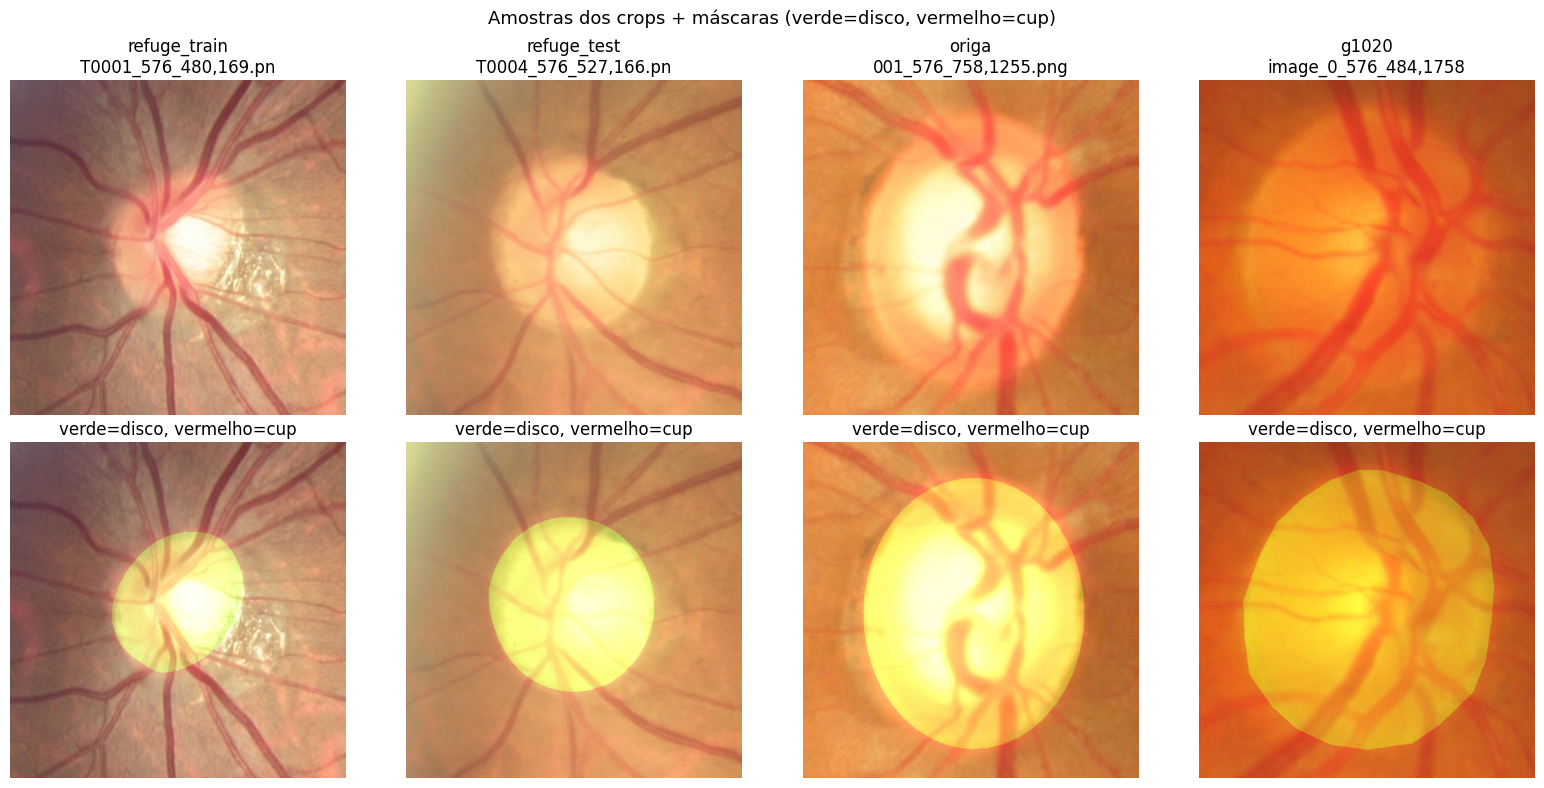


=== Resumo final ===
  refuge_train        : 960 crops
  refuge_test         : 240 crops
  origa               : 650 crops
  g1020               : 1020 crops


: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
datasets  = ['refuge_train', 'refuge_test', 'origa', 'g1020']

for col, ds in enumerate(datasets):
    img_dir  = os.path.join(DATA_DIR, ds, 'images')
    mask_dir = os.path.join(DATA_DIR, ds, 'masks')

    sample = sorted(os.listdir(img_dir))[0]
    img    = np.array(Image.open(os.path.join(img_dir, sample)).convert('RGB'))
    mask   = np.array(Image.open(os.path.join(mask_dir, sample)))

    # Overlay colorido
    overlay = img.copy()
    if mask.ndim == 3:
        disc_region = mask[:, :, 0] > 0
        cup_region  = mask[:, :, 1] > 0
    else:
        disc_region = mask >= 1
        cup_region  = mask >= 2

    overlay[disc_region, 1] = np.clip(
        overlay[disc_region, 1].astype(int) + 60, 0, 255)
    overlay[cup_region,  0] = np.clip(
        overlay[cup_region,  0].astype(int) + 60, 0, 255)

    axes[0, col].imshow(img)
    axes[0, col].set_title(f'{ds}\n{sample[:20]}')
    axes[0, col].axis('off')

    axes[1, col].imshow(overlay)
    axes[1, col].set_title('verde=disco, vermelho=cup')
    axes[1, col].axis('off')

plt.suptitle('Crop samples + masks (green=disc, red=cup)', fontsize=13)
plt.tight_layout()
plt.show()

# Resumo final
print('\n=== Resumo final ===')
for ds in datasets:
    n = len(os.listdir(os.path.join(DATA_DIR, ds, 'images')))
    print(f'  {ds:20s}: {n} crops')

## Output structure

```
segtran-master/data/fundus/
├── refuge_train/          (960 crops — SegTran training)
│   ├── images/            560×560 px RGB
│   ├── masks/             560×560 px, 3 channels (disc+cup | cup | 0)
│   ├── mnet_predictions/  MNet predictions (for reference)
│   ├── all.list
│   ├── train.list
│   └── test.list
├── refuge_test/           (240 crops — teste ID)
├── origa/                 (650 crops — OOD)
└── g1020/                 (2040 crops — OOD)

segtran-master/code/MNet_DeepCDR/deep_model/
└── Model_MNet_REFUGE_finetuned.h5  (MNet fine-tunado)
```

Next step: run `06_train_inference_SegTran_OpticCup.ipynb`.